# Sponsor synonym distributions — observed vs Poisson vs Negative Binomial

Pure analysis of the **already-saved** sampling results
(`sponsor_synonym_stratified_results.json`) — **no LLM, no rerun**. It reconstructs
the per-record synonym-count distribution per stratum, fits Poisson and Negative
Binomial, charts all three, and reports the implied true unique-organization count
under each model.

Key idea: per-record synonym counts are **overdispersed** (excess zeros + a heavy
tail) relative to Poisson, most strongly for INDUSTRY (parent/subsidiary sprawl).
The NB fit captures that; for the org count it is fit to **two** moments (pairs
*and* prevalence), where the single-rate Poisson can only match one.

In [1]:
import json, collections, math
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
from scipy.optimize import brentq

RESULTS = "sponsor_synonym_stratified_results.json"   # run this notebook from notebooks/
R = json.load(open(RESULTS))
by = collections.defaultdict(list)
for r in R: by[r["stratum"]].append(r)
STRATA = list(by)
print("strata:", STRATA, "| samples each:", {s: len(by[s]) for s in STRATA})

def per_record_counts(rows):
    """Per-record observed synonym-count distribution (incl. zeros) for one stratum.
    A member of an observed group of size L has (L-1) co-sampled synonyms."""
    n = rows[0]["n_sample"]; total = n*len(rows)
    cnt = collections.Counter()
    for r in rows:
        for L in r["group_sizes"]:
            cnt[L-1] += L
    cnt[0] = total - sum(cnt.values())
    return cnt, total

strata: ['INDUSTRY', 'OTHER', 'UNKNOWN'] | samples each: {'INDUSTRY': 20, 'OTHER': 20, 'UNKNOWN': 20}


## 1. Per-record observed synonym-count distribution + overdispersion

In [2]:
rows_tbl = []
COUNTS = {}
for cls in STRATA:
    rows = by[cls]
    cnt, total = per_record_counts(rows)
    COUNTS[cls] = (cnt, total)
    ks = np.arange(0, max(cnt)+1)
    obs = np.array([cnt.get(int(k),0) for k in ks], float)
    m = (ks*obs).sum()/total
    v = ((ks**2)*obs).sum()/total - m*m
    rows_tbl.append({"stratum": cls, "records": total, "mean": round(m,4),
                     "var": round(v,4), "overdispersion (var/mean)": round(v/m,2),
                     "max count": int(ks.max())})
print(pd.DataFrame(rows_tbl).to_string(index=False))

 stratum  records   mean    var  overdispersion (var/mean)  max count
INDUSTRY    40000 0.0772 0.2278                       2.95          7
   OTHER    40000 0.0090 0.0107                       1.19          3
 UNKNOWN    40000 0.0368 0.0518                       1.41          5


## 2. Fit Poisson and Negative Binomial to the observed counts

In [3]:
def fits_for(cls):
    cnt, total = COUNTS[cls]
    ks = np.arange(0, max(cnt)+1)
    obs = np.array([cnt.get(int(k),0) for k in ks], float) / total
    m = (ks*obs).sum(); v = (ks**2*obs).sum() - m*m
    # Poisson: lambda = mean
    pois = poisson.pmf(ks, m)
    # NB by method of moments (var>mean): scipy nbinom(n=r, p), mean=r(1-p)/p
    if v > m:
        r = m*m/(v-m); p = m/v
        nb = nbinom.pmf(ks, r, p)
    else:
        r = p = np.nan; nb = pois
    return ks, obs, pois, nb, m, v, r, p

for cls in STRATA:
    ks, obs, pois, nb, m, v, r, p = fits_for(cls)
    df = pd.DataFrame({"k": ks, "observed": obs.round(5),
                       "Poisson": pois.round(5), "NegBinom": nb.round(5)})
    print(f"\n=== {cls} ===  Poisson lambda={m:.4f}   NB r={r:.4f} p={p:.4f}")
    print(df.to_string(index=False))


=== INDUSTRY ===  Poisson lambda=0.0771   NB r=0.0395 p=0.3387
 k  observed  Poisson  NegBinom
 0   0.95938  0.92575   0.95812
 1   0.02460  0.07142   0.02503
 2   0.00698  0.00276   0.00861
 3   0.00380  0.00007   0.00387
 4   0.00188  0.00000   0.00194
 5   0.00135  0.00000   0.00104
 6   0.00122  0.00000   0.00058
 7   0.00080  0.00000   0.00033

=== OTHER ===  Poisson lambda=0.0090   NB r=0.0471 p=0.8396
 k  observed  Poisson  NegBinom
 0    0.9918  0.99104   0.99180
 1    0.0075  0.00892   0.00749
 2    0.0006  0.00004   0.00063
 3    0.0001  0.00000   0.00007

=== UNKNOWN ===  Poisson lambda=0.0369   NB r=0.0906 p=0.7108
 k  observed  Poisson  NegBinom
 0   0.96928  0.96382   0.96956
 1   0.02595  0.03552   0.02540
 2   0.00398  0.00065   0.00400
 3   0.00040  0.00001   0.00081
 4   0.00025  0.00000   0.00018
 5   0.00015  0.00000   0.00004


## 3. Chart — observed vs Poisson vs Negative Binomial

Log y-axis (the distribution is mostly zeros). Where the Poisson line falls *below*
the observed bars in the tail, that gap is the overdispersion the NB recovers.

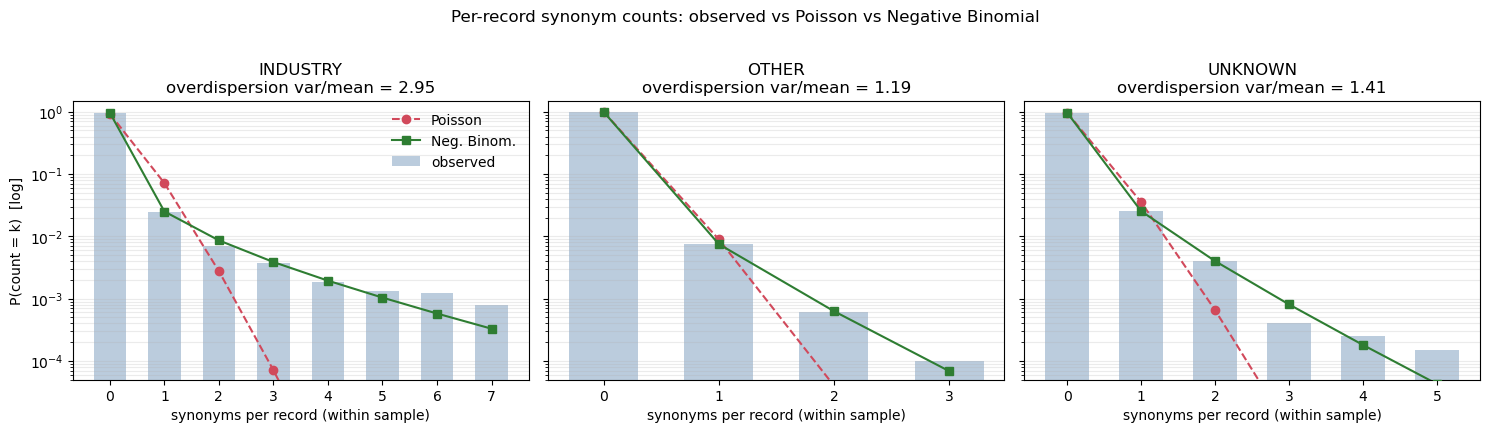

In [4]:
fig, axes = plt.subplots(1, len(STRATA), figsize=(5*len(STRATA), 4.2), sharey=True)
if len(STRATA)==1: axes=[axes]
for ax, cls in zip(axes, STRATA):
    ks, obs, pois, nb, m, v, r, p = fits_for(cls)
    ax.bar(ks, obs, width=0.6, color="#bcd", label="observed", zorder=1)
    ax.plot(ks, pois, "o--", color="#d1495b", label="Poisson", zorder=3)
    ax.plot(ks, nb,   "s-",  color="#2e7d32", label="Neg. Binom.", zorder=3)
    ax.set_yscale("log"); ax.set_ylim(max(1e-6, obs[obs>0].min()/3), 1.5)
    ax.set_xlabel("synonyms per record (within sample)")
    ax.set_title(f"{cls}\noverdispersion var/mean = {v/m:.2f}")
    ax.set_xticks(ks)
    ax.grid(True, which="both", axis="y", alpha=0.25)
axes[0].set_ylabel("P(count = k)  [log]")
axes[0].legend(frameon=False)
fig.suptitle("Per-record synonym counts: observed vs Poisson vs Negative Binomial", y=1.02)
fig.tight_layout()
fig.savefig("sponsor_synonym_distributions.png", dpi=130, bbox_inches="tight")
plt.show()

## 4. Implied true unique organizations — Poisson vs Negative Binomial

Org-level model: group size `K = 1 + extra`, `extra` ~ Poisson(theta) or NB.
- **Poisson** is fit to one moment, pairs-per-name `rho = P/N`  ->  `theta`, `G = N/(1+theta)`.
- **NB** is fit to **two** moments — `rho` *and* prevalence — so it honours the
  measured fraction of names in a group, which Poisson cannot (it over-predicts it
  for INDUSTRY). `G = N/(1+mu)`.
All figures are **floors** (LLM recall < 1; cross-stratum pairs unseen).

In [5]:
def org_estimates(rows):
    n=rows[0]["n_sample"]; N=rows[0]["n_total"]; X=len(rows)
    pi2=n*(n-1)/(N*(N-1))
    op=sum(r["pairs"] for r in rows); oin=sum(r["names_in_groups"] for r in rows)
    P=op/(X*pi2); rho=P/N; prev=(oin/op)*P/N
    theta=rho-1+math.sqrt(1+rho*rho); G_p=N/(1+theta)
    def mu_of_k(k):
        a=1+1/k; return (-(1-rho)+math.sqrt((1-rho)**2+2*a*rho))/a
    def prev_of_k(k):
        mu=mu_of_k(k); return 1-(1+mu/k)**(-k)/(1+mu)
    try:
        k=brentq(lambda kk: prev_of_k(kk)-prev, 1e-3, 1e4); mu=mu_of_k(k); G_nb=N/(1+mu)
    except ValueError:
        k=mu=np.nan; G_nb=G_p
    return N, P, prev, theta, G_p, mu, k, G_nb

tbl=[]; tot=dict(N=0,Gp=0,Gnb=0)
for cls in STRATA:
    N,P,prev,theta,G_p,mu,k,G_nb = org_estimates(by[cls])
    tot["N"]+=N; tot["Gp"]+=G_p; tot["Gnb"]+=G_nb
    tbl.append({"stratum":cls,"names":N,"prevalence":f"{prev:.1%}",
                "Poisson theta":round(theta,3),"Poisson orgs":round(G_p),
                "Poisson redund":round(N-G_p),
                "NB k(dispersion)":round(k,3),"NB orgs":round(G_nb),
                "NB redund":round(N-G_nb)})
print(pd.DataFrame(tbl).to_string(index=False))
print(f"\nTOTAL (measured strata)  names={tot['N']:,}")
print(f"  true unique orgs:  Poisson ~{tot['Gp']:,.0f}   NB ~{tot['Gnb']:,.0f}")
print(f"  redundancy:        Poisson ~{tot['N']-tot['Gp']:,.0f}   NB ~{tot['N']-tot['Gnb']:,.0f}")
print("  (+ ~1,500 small-stratum names ~1:1; all FLOORS)")

 stratum  names prevalence  Poisson theta  Poisson orgs  Poisson redund  NB k(dispersion)  NB orgs  NB redund
INDUSTRY   7226      14.7%          0.149          6288             938             0.092     6587        639
   OTHER  15783       6.5%          0.036         15232             551             0.365    15256        527
 UNKNOWN  12973      19.9%          0.127         11514            1459             0.830    11601       1372

TOTAL (measured strata)  names=35,982
  true unique orgs:  Poisson ~33,035   NB ~33,444
  redundancy:        Poisson ~2,947   NB ~2,538
  (+ ~1,500 small-stratum names ~1:1; all FLOORS)


## 5. Reading it

- **OTHER (academic)** is nearly Poisson (overdispersion ≈ 1.2) — scattered random
  pairs; Poisson and NB agree on the org count.
- **INDUSTRY** is strongly overdispersed (≈ 3.0) — parent/subsidiary/legal-entity
  families. Poisson over-states the collapse; the NB (fitting prevalence too) says
  industry collapses **less** than Poisson implied — fewer names are affected, but
  the affected ones sit in bigger families.
- **UNKNOWN** is in between.
- Net: the ~37.5k names represent on the order of **~33–35k true organizations**
  (a floor). The exact number is model-sensitive where overdispersion is high
  (industry); the definitive count falls out of actually running the clustering
  oracle. The chart is the evidence that NB, not Poisson, is the right shape there.